# Lab: Classification
## CMSE 381 - Spring 2022
## Feb 11, 2022



##ANSWER## 

Notes from 2/11/22: THis one ran rather short.  Also could include something with the p-values but I couldn't find it in sklearn when i wrote this. 

In this module we are going to test out the classification methods we discussed in class 

## Getting a feel for the data

We're going to use the `Smarket` data set from the ISLR book as included in their R package.  I've included a csv with this notebook for you to use. 

This data set consists of percentage returns for the S&P 500 stock index over 1,250 days, from the beginning of 2001 until the end of 2005. For each date, we have recorded the percentage returns for each of the five previous trading days, `Lag1` through `Lag5`. We have also recorded `Volume` (the number of shares traded on the previous day, in billions), `Today` (the percentage return on the date in question) and `Direction` (whether the market was `Up` or `Down` on this date). Our goal is to predict `Direction` (a qualitative response) using the other features.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
%matplotlib inline
import seaborn as sns

In [2]:
smarket = pd.read_csv('Smarket.csv', index_col = 0)

In [3]:
smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
3,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
4,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
5,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1246,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1247,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1248,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1249,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


Note that the `Year` column only has the year information.  In the case of this data, the sorted order tracks the days, so be sure to not accidentally shuffle it! 

&#9989; **<font color=red>Do this:</font>** Write a brief description of the data set. Which of the available variables are quantitative? Which are categorical? Draw some plots of the data and get a feel for what the columns mean. 

In [4]:
# Your code here #

In [5]:
##ANSWER##

smarket.describe()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


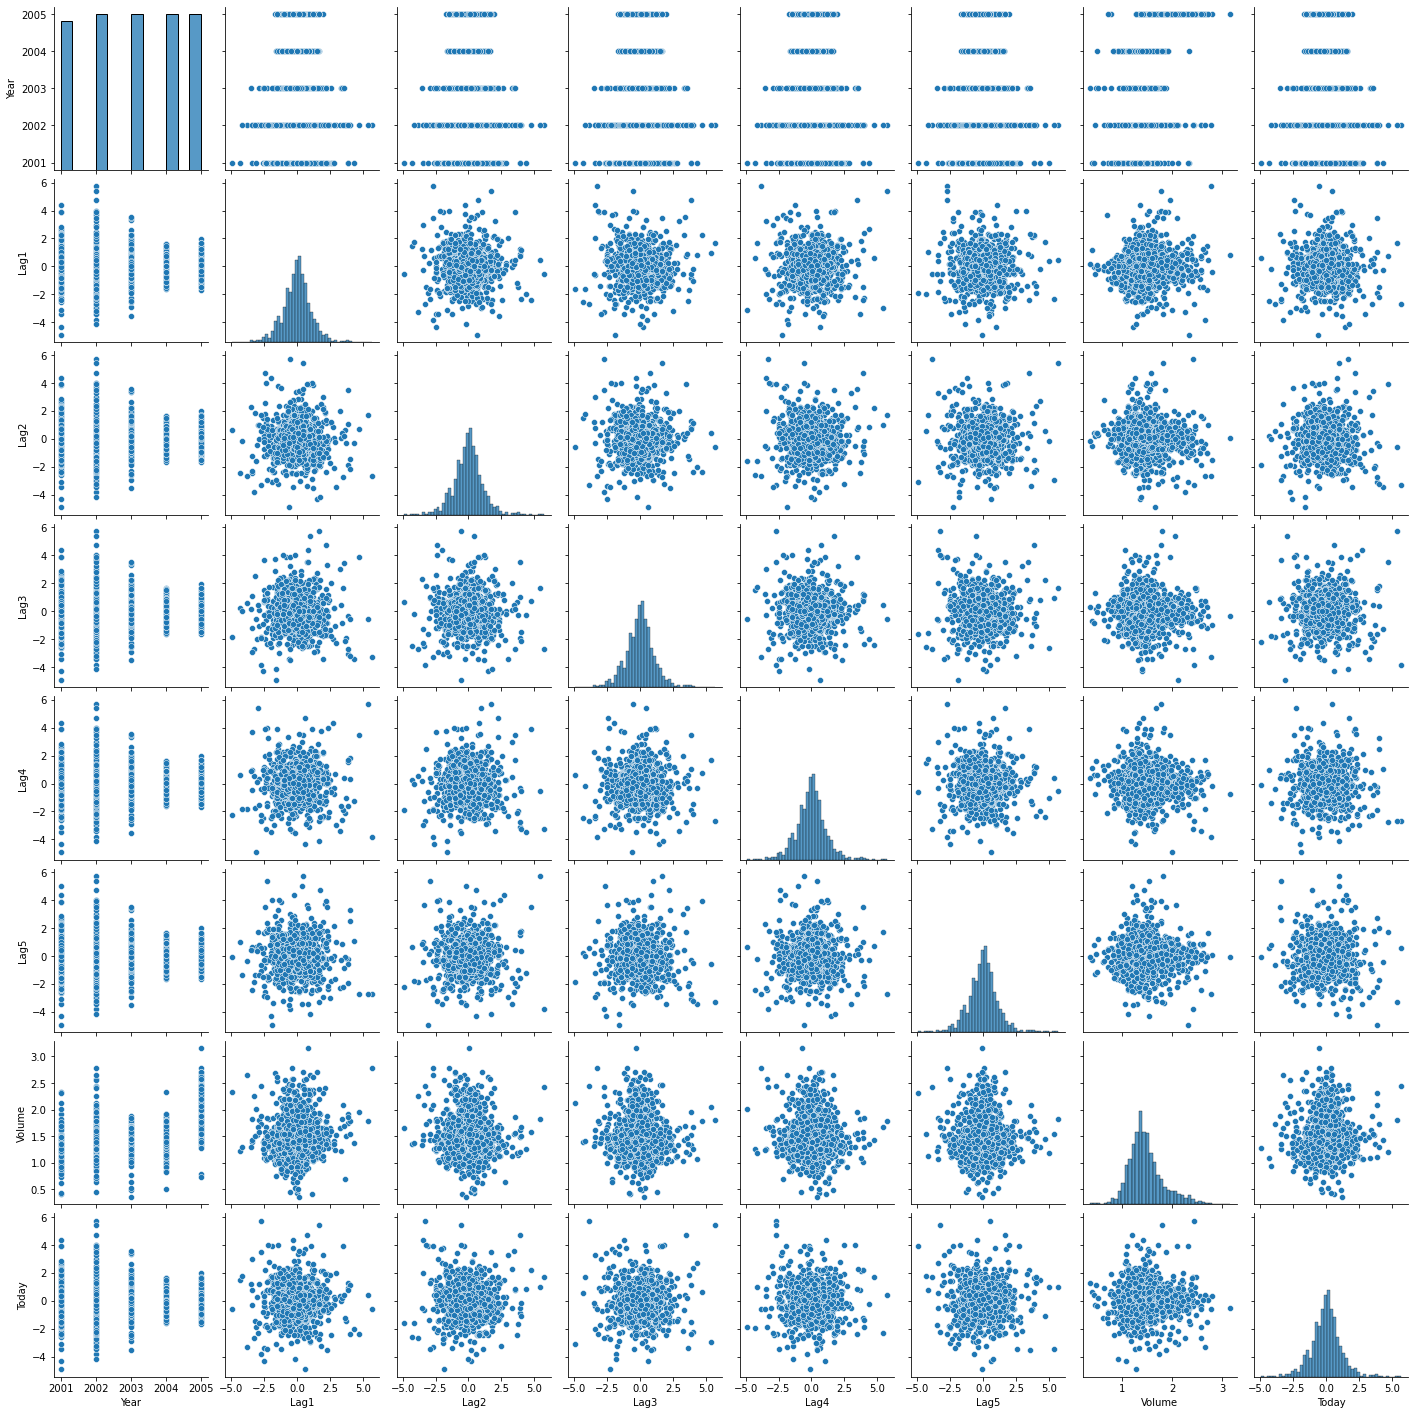

In [6]:
##ANSWER## 
sns.pairplot(smarket)

&#9989; **<font color=red>Do this:</font>** Take a look at the correlation matrix, which can be found with `dataframe.corr()`. Does it include all of the variables in the data set? What do you notice about the correlations?

*Hint: A great way to see what's going on with a matrix is to use the `plt.matshow` command.*

In [7]:
# Your code here #

In [8]:
##ANSWER##
# Correlation matrix.  Note that it drops the direction
# column because that has object data
smarket.corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


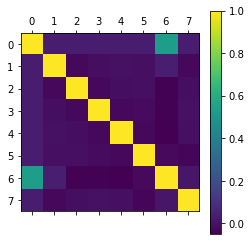

In [9]:
##ANSWER##

plt.matshow(smarket.corr())
plt.colorbar()

# Note that most values are 0, makes sense because yesterday's 
# returns not related to previous
# However, there is a correlation between year and volume

&#9989; **<font color=red>Q:</font>** Do some further investigation on the high correlation value you saw in the previous step. Can you justify why that particular pair of variables has a high correlation? 

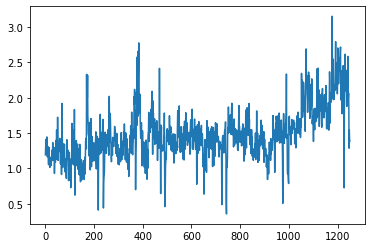

In [10]:
##ANSWER##


# Plot the time series. We see that there is a general positive trend
# which explains the high correlation between year and volume.

# Note that if you do year against time,
# it ends up chunked up, so in this case the fact that the data 
# is ordered is important. 
plt.plot(smarket.Volume)

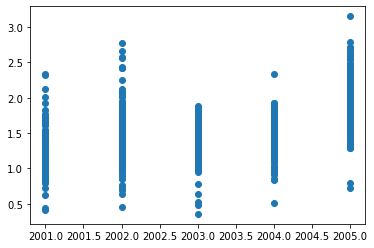

In [11]:
##ANSWER##

# Students will likely end up with this plot which isn't particularly
# useful.

plt.scatter(smarket.Year, smarket.Volume)

## Classification using Logistic Regression

Our goal is to predict `Direction`, a categorical variable taking as values the strings `Up` and `Down`.


For this module, we will largely use the tools from `sklearn`  for classification. One of the big perks of the `sklearn` module is that there is a great deal of uniformity in the classes. So once we have a handle on how to interact with one kind of classification tool, very minor tweaks in the code will allow for the use of a new model. In fact, many of the things we'll do today should look very similar in terms of the syntax to the linear regression lab from a few weeks ago. 

For our first try doing classification, we'll use `LogisticRegression` from the `sklearn.linear_model` module. I'm a huge fan of the `sklean` documentaiton since it includes a great deal of info on the math behind what we're doing as well as explanations on the code:
- [`sklearn` mathematical description of logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [`LogisticRegression` class documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)

In [12]:
from sklearn.linear_model import LogisticRegression 

Lets first predict `Direction` using `Lag1`,`Lag2` and `Volume`. 
Our first job is to extract the portion of the dataframe that we want to use. `sklearn` is happiest when we hand it an array. 

In [13]:
X = np.array(smarket[['Lag1','Lag2','Volume']])
Y = np.array(smarket.Direction)

In [14]:
print(X.shape)
print(Y.shape)

(1250, 3)
(1250,)


Once we have our data, we create an instance of the model class we want, in this case `LogisticRegression`, and fit the model to the data. Note the `random_state=0` code ensures that rerunning the following box will return the same answer every time. 

In [15]:
clf = LogisticRegression(random_state=0)
clf.fit(X,Y)


LogisticRegression(random_state=0)

Great, that was easy! Once we've fit the model, the main task is to understand how to extract information from it. 

&#9989; **<font color=red>Do this:</font>** Extract the coefficients and intercept from the trained model. *(Note: You might need to take a look at the documentation to figure out how to do that.)* What is the equation, in terms of the variables used, that you are modeling? 

In [16]:
# Your code here

In [17]:
##ANSWER##
print(clf.coef_)
print(clf.intercept_)

[[-0.07302967 -0.04272162  0.12862433]]
[-0.1158254]


##ANSWER##
To get the equation, they'll have to look back at either the slides or Sec 4.3.4. There we get that 
$$
p(X) = \frac{\exp(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p)}{1+\exp(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p)}
$$
so in this case the equation is 
$$
p(X) = \frac{\exp(-0.115 -0.073 \cdot \texttt{Lag1} -0.043 \cdot  \texttt{Lag2}  + 0.129  \cdot \texttt{Volume})}{1+\exp(-0.115 -0.073 \cdot \texttt{Lag1} -0.043 \cdot  \texttt{Lag2}  + 0.129  \cdot \texttt{Volume})}
$$

Thing I don't know: Pretty sure this is the probability that $Y = \texttt{Down}$ since \texttt{Down} is first in the list  of classes, but that is probably something I should double check at some point. 

While it's good to know what equation we're modeling with, the big perk here is that your `sklearn` class will evaluate the data points of your model for you. Yay!

&#9989; **<font color=red>Do this:</font>** Use the `predict_proba` function to determine the probabilities $Pr(Y = \texttt{Down} \mid X)$ for the data set. What shape is the output matrix? Why that shape? What do the columns represent?

In [18]:
# Your code here

##ANSWER##

Predict proba (from the documentation)

Probability estimates.

The returned estimates for all classes are ordered by the label of classes.

For a multi_class problem, if multi_class is set to be “multinomial” the softmax function is used to find the predicted probability of each class. Else use a one-vs-rest approach, i.e calculate the probability of each class assuming it to be positive using the logistic function. and normalize these values across all the classes.

In [19]:
##ANSWER##

# Checking up on the order of classes 

clf.classes_

array(['Down', 'Up'], dtype=object)

In [ ]:
##ANSWER## 
# Predicting probabilities. The columns are aligned to the order of classes, so the
# first column is the probability of down, the second is the probability of up.
clf.predict_proba(X)

Of course this gives us the probability of each each label for a given data, but we really would like to have the prediction itself. 


&#9989; **<font color=red>Do this:</font>** Use the `predict` function to determine the predictions for each input data point in the original $X$ matrix and store the output as `Yhat`. How many predictions are different than the actual `Direction` value? Whats the percent error for the model?

In [18]:
# Your code here

In [27]:
##ANSWER##
Yhat = clf.predict(X)
Yhat

array(['Up', 'Down', 'Down', ..., 'Up', 'Up', 'Up'], dtype=object)

In [28]:
##ANSWER##
# Figure out which entries aren't the same. Sum will just count the number of True entries
# so gives the number of predictions that are different. 
sum(Y != Yhat)

583

In [29]:
##ANSWER##

# Percent error: 
sum(Y != Yhat)/len(Y)

0.4664


&#9989; **<font color=red>Do this:</font>** An even easier way of figuring out the error rate is through the score. What does the output of `clf.score(X,Y)` mean and how is it related to the number you determined above?

In [18]:
# Your code here

In [36]:
##ANSWER##
# Another way to get the answer is to just use the score function which gives the percent correct.
print('Score:', clf.score(X,Y))
print('1-Score is error:', 1-clf.score(X,Y))

Score: 0.5336
1-Score is error: 0.46640000000000004


**Confusion matrix**

As we saw in class, the percent error is a rather limited way of evaluating the classification model. Luckily `sklearn` provides commands for computing the confusion matrix for a given model easily. The `confusion_matrix` command computes the confusion matrix, and `ConfusionMatrixDisplay` gives a nice visual representation. 

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [34]:
# This code gives the confusion matrix, assuming you stored the predicted values as `Yhat`.
C = confusion_matrix(Y,Yhat)

C

array([[147, 455],
       [128, 520]])

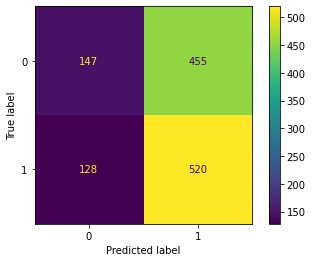

In [35]:
# This code gives a visual representation 
ConfusionMatrixDisplay(C).plot()



&#9989; **<font color=red>Q:</font>** The makers of `sklearn` made a PARTICULARY strange choice when it comes to the confusion matrix representation.  What is different about the `sklearn` confusion matrix from how we saw it in class?

*Your answer here*

##ANSWER## 

*They put true label on the rows and predicted on the columns. We did the transpose in class. I've seen it as the transpose literally everywhere but in this code. Yarg.*

**A simple validation set**

In the next lab we will investigate more complex methods of validation sets, but for now let's split up the data into two pieces. 
We will use the data from 2004 and before as training data, and reserve the 2005 data for testing.

In [62]:
X_train = smarket[smarket.Year<=2004][['Lag1','Lag2','Volume']]
Y_train = smarket[smarket.Year<=2004].Direction

X_test  = smarket[smarket.Year >2004][['Lag1','Lag2','Volume']]
Y_test  = smarket[smarket.Year >2004].Direction




&#9989; **<font color=red>Do this:</font>** Train the logistic regression model on the `X_train` data. What is the score on the `X_test` data?

In [18]:
# Your code here

In [64]:
##ANSWER##

clf = LogisticRegression()
clf.fit(X_train,Y_train)

clf.score(X_test,Y_test)

0.4801587301587302

## LDA 

Now the great perk of `sklearn` is that it's quite easy to swap out our code for a new model. Here's the documentation links for Linear Discriminant Analysis. 

- [Documentation for `LinearDiscriminantAnalysis`](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)
- [Discussion of the mathematics](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda)

In [67]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [68]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)

LinearDiscriminantAnalysis()


&#9989; **<font color=red>Do this:</font>** What are the predictions on the test data set? What is the score? 

In [69]:
# Your answer here

In [70]:
##ANSWER##
lda.predict(X_test)

array(['Up', 'Up', 'Up', 'Up', 'Up', 'Up', 'Up', 'Up', 'Up', 'Up', 'Up',
       'Down', 'Up', 'Up', 'Up', 'Up', 'Down', 'Down', 'Down', 'Up',
       'Down', 'Down', 'Down', 'Up', 'Down', 'Down', 'Up', 'Up', 'Up',
       'Down', 'Up', 'Down', 'Up', 'Up', 'Up', 'Up', 'Up', 'Down', 'Down',
       'Down', 'Down', 'Down', 'Up', 'Down', 'Down', 'Up', 'Up', 'Up',
       'Up', 'Up', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down', 'Down',
       'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down',
       'Down', 'Up', 'Up', 'Down', 'Down', 'Up', 'Up', 'Down', 'Down',
       'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down',
       'Down', 'Down', 'Down', 'Down', 'Up', 'Down', 'Down', 'Up', 'Down',
       'Up', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Up',
       'Down', 'Down', 'Up', 'Down', 'Down', 'Up', 'Up', 'Down', 'Up',
       'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down', 'Down',
       'Up', 'Down', 'Up', 'Down', 'Up', 'Down', 'Down', 'Down'

In [72]:
##ANSWER##
lda.score(X_test,Y_test)

0.47619047619047616

## QDA

Now that we're seeing the pattern, you should be able to do the same things for quadratic discriminant anlysis, given the following import. 

- Fit the QDA model on the training data
- Determine the predictions for the testing data. 
- Get the score for the model. Is this an improvement from the previous models? 

In [73]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


In [48]:
# Your code here # 

In [74]:
##ANSWER##
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train,Y_train)
qda.predict(X_test)
qda.score(X_test,Y_test)

0.45634920634920634

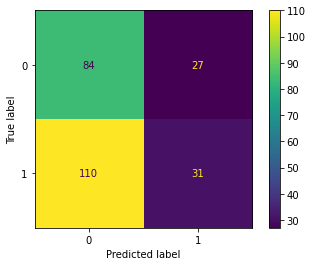

In [75]:
##ANSWER##

C = confusion_matrix(Y_test,qda.predict(X_test))

ConfusionMatrixDisplay(C).plot()


# Next step 

If you have remaining time, your homework problem for today's lab is 4.8.13 parts (a-f, i).  Get started on the problem, feel free to work through it with your group. This will require the `Weekly.csv` data set included with the lab.


# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [79]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

In [80]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-Classification-INSTRUCTOR.ipynb


Lab-Classification.ipynb


Validating Notebook ./Lab-Classification.ipynb


0